In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [3]:
# Dataset Information
print("Dataset Name:", data.DESCR[:300])
print("\nFeature Names:")
print(data.feature_names)
print("\nTarget Names:")
print(data.target_names)

Dataset Name: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of dista

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']


In [4]:
# Convert dataset to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [5]:
# Check dataset information
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum().sum())
print("\nClass Distribution:")
print(df["target"].value_counts())

Dataset Shape: (569, 31)

Missing Values:
0

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [6]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [7]:
# Train Random Forest with 100 trees
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [8]:
# Compare different numbers of trees
tree_values = [10, 50, 100, 200, 500]
accuracies = []
for trees in tree_values:
    model = RandomForestClassifier(n_estimators=trees,random_state=42)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)
    print(f"Trees: {trees} | Accuracy: {acc:.4f}")

Trees: 10 | Accuracy: 0.9561
Trees: 50 | Accuracy: 0.9649
Trees: 100 | Accuracy: 0.9649
Trees: 200 | Accuracy: 0.9649
Trees: 500 | Accuracy: 0.9649


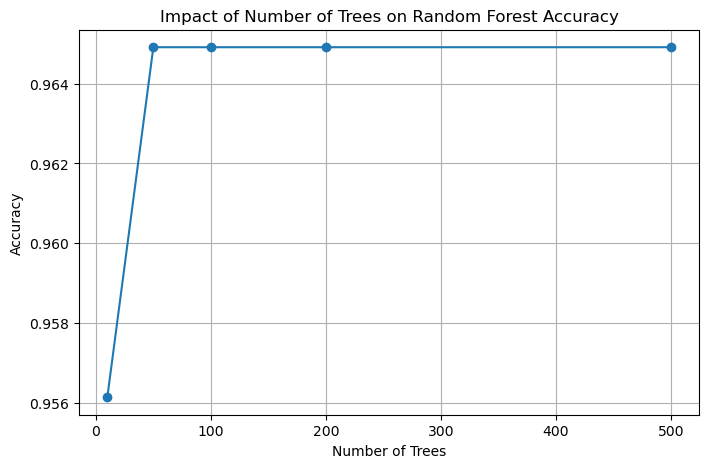

In [9]:
# Accuracy vs Number of Trees
plt.figure(figsize=(8,5))
plt.plot(tree_values,accuracies,marker="o")
plt.title("Impact of Number of Trees on Random Forest Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [10]:
# Feature Importance Analysis
feature_importance = rf.feature_importances_
feature_names = data.feature_names
importance_df = pd.DataFrame({"Feature": feature_names,"Importance": feature_importance})
importance_df = importance_df.sort_values(by="Importance",ascending=False)
print(importance_df.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


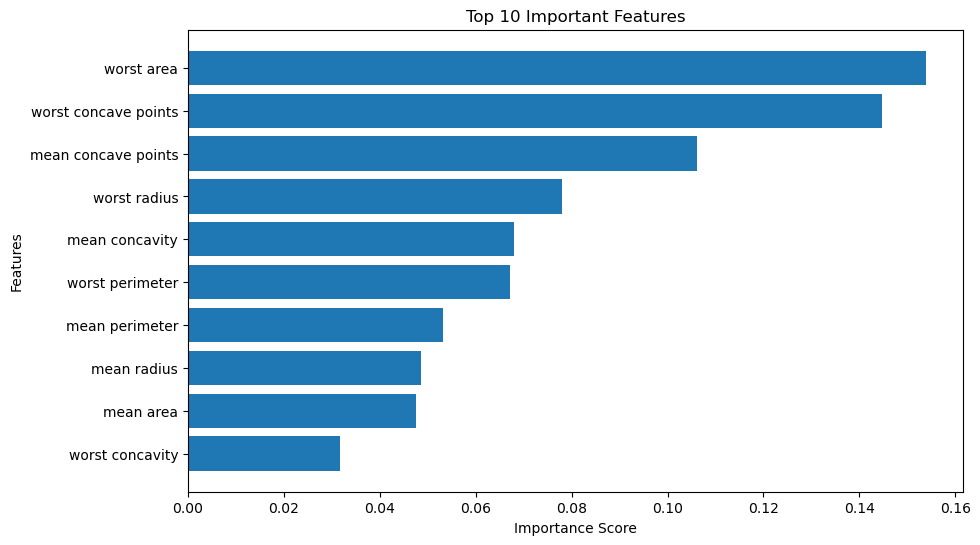

In [11]:
# Top 10 Important Features
top_features = importance_df.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"],top_features["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

[[40  3]
 [ 1 70]]


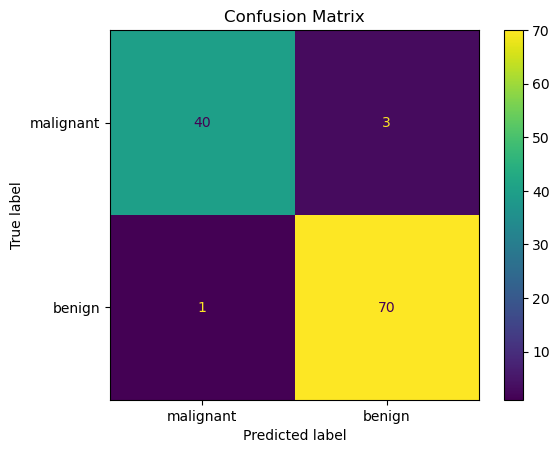

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=data.target_names)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [14]:
print("Final Conclusion")
print("""1. Random Forest achieved approximately 96% accuracy.
2. Increasing the number of trees improved performance initially.
3. After around 50 trees, accuracy became stable.
4. The most important features were:
   - worst area
   - worst concave points
   - mean concave points
5. Random Forest is effective for breast cancer classification.
""")

Final Conclusion
1. Random Forest achieved approximately 96% accuracy.
2. Increasing the number of trees improved performance initially.
3. After around 50 trees, accuracy became stable.
4. The most important features were:
   - worst area
   - worst concave points
   - mean concave points
5. Random Forest is effective for breast cancer classification.

